In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import os
import matplotlib as plt

os.chdir('/Users/ijaejun/Documents/sophomore_high/crime_catchers')


plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data/processed/final_data.csv', encoding='utf-8-sig')

# 독립변수 / 종속변수 설정
feature_cols = ['실업률', '음주율', '물가상승률', '인구수', '평균기온',
                '경찰1인당주민수', '기초수급비율(%)', '조이혼율', '지역소득', '외국인비율(%)']

X = df[feature_cols]
y = df['범죄율']

# 지역 더미변수 생성 (drop_first=True)
region_dummies = pd.get_dummies(df['지역'], prefix='지역', drop_first=True, dtype=int)
X = pd.concat([X, region_dummies], axis=1)

In [2]:
# ── 1. VIF 계산 후 10 이상인 변수 단계적 제거 ──────────────────────────────
def calc_vif(X):
    X_const = sm.add_constant(X)
    vif = pd.DataFrame()
    vif['변수'] = X_const.columns
    vif['VIF'] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]
    return vif[vif['변수'] != 'const'].reset_index(drop=True)

X_selected = X.copy()
step = 1
while True:
    vif_data = calc_vif(X_selected).sort_values('VIF', ascending=False)
    print(f"📊 Step {step} VIF 결과:")
    print(vif_data.to_string(index=False))

    max_row = vif_data.iloc[0]
    if max_row['VIF'] >= 10:
        drop_var = max_row['변수']
        print(f"⚠️ VIF {max_row['VIF']:.2f} ≥ 10 → '{drop_var}' 제거\n")
        X_selected = X_selected.drop(columns=[drop_var])
        step += 1
    else:
        print("\n✅ 모든 변수 VIF < 10 → 제거 종료")
        break

📊 Step 1 VIF 결과:
       변수        VIF
      인구수 745.112782
    지역_부산 562.394727
    지역_인천 364.643547
    지역_대구 136.628057
    지역_울산 129.870448
     지역소득 105.722426
기초수급비율(%)  41.769264
     평균기온  20.723226
     조이혼율  16.698909
 경찰1인당주민수  16.464409
 외국인비율(%)  15.351991
    지역_대전   5.200165
    물가상승률   4.945869
      실업률   4.202892
      음주율   3.706548
⚠️ VIF 745.11 ≥ 10 → '인구수' 제거

📊 Step 2 VIF 결과:
       변수        VIF
    지역_울산 111.470465
     지역소득 104.637625
기초수급비율(%)  33.517264
    지역_인천  32.043515
     평균기온  20.707822
 경찰1인당주민수  15.976501
 외국인비율(%)  14.889123
     조이혼율  14.887076
    지역_부산   6.328157
    지역_대전   5.197346
    물가상승률   4.861585
      실업률   4.168197
      음주율   3.648693
    지역_대구   3.140914
⚠️ VIF 111.47 ≥ 10 → '지역_울산' 제거

📊 Step 3 VIF 결과:
       변수       VIF
    지역_인천 30.035367
기초수급비율(%) 28.858195
     평균기온 20.673238
 경찰1인당주민수 15.231808
     조이혼율 14.368109
     지역소득 13.904412
 외국인비율(%) 13.752128
    지역_부산  6.252000
    물가상승률  4.677555
      실업률  3.967033
      음주율  3.3

In [3]:
# ── 2. 최종 변수로 OLS 다중 선형회귀분석 ──────────────────────────────
X_final = sm.add_constant(X_selected)
model = sm.OLS(y, X_final).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    범죄율   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     18.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           4.33e-14
Time:                        09:18:02   Log-Likelihood:                -355.74
No. Observations:                  66   AIC:                             733.5
Df Residuals:                      55   BIC:                             757.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        244.3298    161.426      1.514      0.1

In [4]:
# ── 3. 결과 정리 ──────────────────────────────
print("✅ 최종 선택된 변수:")
print(X_selected.columns.tolist())

print(f"\n✅ R-squared: {model.rsquared:.4f}")
print(f"✅ Adj. R-squared: {model.rsquared_adj:.4f}")
print(f"✅ F-statistic p-value: {model.f_pvalue:.4e}")

# 표준화 회귀계수로 영향력 비교 (단위 차이를 보정)
beta = model.params.drop('const')
std_coef = (beta * X_selected.std() / y.std()).abs().sort_values(ascending=False)

print("\n🏆 영향력 큰 변수 Top 3 (표준화 계수 기준):")
for i, (var, val) in enumerate(std_coef.head(3).items(), 1):
    print(f"{i}. {var}  (표준화 계수: {val:.4f}, 회귀계수: {model.params[var]:.4f}, p-value: {model.pvalues[var]:.4f})")
print(model.summary())


✅ 최종 선택된 변수:
['실업률', '음주율', '물가상승률', '경찰1인당주민수', '조이혼율', '지역소득', '외국인비율(%)', '지역_대구', '지역_대전', '지역_부산']

✅ R-squared: 0.7680
✅ Adj. R-squared: 0.7259
✅ F-statistic p-value: 4.3266e-14

🏆 영향력 큰 변수 Top 3 (표준화 계수 기준):
1. 실업률  (표준화 계수: 0.5906, 회귀계수: -105.9049, p-value: 0.0000)
2. 지역소득  (표준화 계수: 0.4259, 회귀계수: -0.0030, p-value: 0.0000)
3. 물가상승률  (표준화 계수: 0.3178, 회귀계수: -24.7685, p-value: 0.0008)
                            OLS Regression Results                            
Dep. Variable:                    범죄율   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     18.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           4.33e-14
Time:                        09:18:02   Log-Likelihood:                -355.74
No. Observations:                  66   AIC:                             733.5
Df Residuals:                      55   BIC:           

## 4. 데이터 및 회귀결과 검증

In [5]:
# ── 4-1. 데이터 검증 ──────────────────────────────
print(f"데이터 shape: {df.shape}  (기대값: 6개 도시 × 11개 연도 = {6*11}행)")

print("\n도시별 관측 연도 수:")
print(df.groupby('지역')['연도'].count())

print(f"\n결측치 총 개수: {df.isnull().sum().sum()}개")

print("\n연도별 범죄율 평균:")
print(df.groupby('연도')['범죄율'].mean().round(2))

# 2018년 전후 비교
before = df[df['연도'] < 2018]['범죄율']
after = df[df['연도'] >= 2018]['범죄율']
diff = after.mean() - before.mean()
print(f"\n2018년 이전(2014~2017, n={len(before)}) 평균 범죄율: {before.mean():.2f}")
print(f"2018년 이후(2018~2024, n={len(after)}) 평균 범죄율: {after.mean():.2f}")
print(f"차이: {diff:.2f}  (변화율 {diff/before.mean()*100:.1f}%)")

데이터 shape: (66, 13)  (기대값: 6개 도시 × 11개 연도 = 66행)

도시별 관측 연도 수:
지역
광주    11
대구    11
대전    11
부산    11
울산    11
인천    11
Name: 연도, dtype: int64

결측치 총 개수: 0개

연도별 범죄율 평균:
연도
2014    860.56
2015    841.48
2016    748.67
2017    701.97
2018    695.51
2019    699.92
2020    647.15
2021    589.91
2022    633.77
2023    646.85
2024    638.94
Name: 범죄율, dtype: float64

2018년 이전(2014~2017, n=24) 평균 범죄율: 788.17
2018년 이후(2018~2024, n=42) 평균 범죄율: 650.29
차이: -137.87  (변화율 -17.5%)


In [6]:
# ── 4-2. 회귀계수 부호 및 통계적 유의성 검토 ──────────────────────────────
# 범죄이론상 기대되는 부호 ('?'는 이론적으로 방향이 정해지지 않은 변수)
expected_sign = {
    '실업률': '+',          # 실업률↑ → 범죄율↑ 예상 (긴장이론)
    '음주율': '+',          # 음주율↑ → 범죄율↑ 예상
    '물가상승률': '?',       # 경제적 압박이론(+) vs 안정적 성장기 동반 상승(-) 등 선행연구마다 방향이 다름
    '경찰1인당주민수': '+',   # 경찰 1인당 담당주민↑(치안인력 부족) → 범죄율↑ 예상
    '조이혼율': '+',         # 가정해체↑ → 범죄율↑ 예상
    '지역소득': '?',         # 박탈이론(-) vs 기회이론(+) 상충
    '외국인비율(%)': '?',    # 선행연구에서도 방향 일관되지 않음
}

print(f"{'변수':<12} {'회귀계수':>12} {'기대부호':^8} {'실제부호':^8} {'일치':^6} {'p-value':>8}")
print("-" * 60)
for var in X_selected.columns:
    coef = model.params[var]
    pval = model.pvalues[var]
    exp = expected_sign.get(var, '?')
    actual = '+' if coef > 0 else '-'
    mark = "✅" if (exp == '?' or exp == actual) else "❌"
    print(f"{var:<12} {coef:>12.4f} {exp:^8} {actual:^8} {mark:^6} {pval:>8.4f}")

print("\n⚠️ p-value ≥ 0.05 (통계적으로 유의하지 않은 변수):")
insig = model.pvalues[model.pvalues >= 0.05].drop('const', errors='ignore')
print(insig if len(insig) else "없음")

변수                   회귀계수   기대부호     실제부호     일치    p-value
------------------------------------------------------------
실업률             -105.9049    +        -       ❌      0.0000
음주율                9.9457    +        +       ✅      0.0037
물가상승률            -24.7685    ?        -       ✅      0.0008
경찰1인당주민수           0.6562    +        +       ✅      0.1235
조이혼율              94.3132    +        +       ✅      0.2063
지역소득              -0.0030    ?        -       ✅      0.0000
외국인비율(%)         -50.5743    ?        -       ✅      0.0466
지역_대구            -24.1394    ?        -       ✅      0.4312
지역_대전              0.2681    ?        +       ✅      0.9927
지역_부산             62.1095    ?        +       ✅      0.1096

⚠️ p-value ≥ 0.05 (통계적으로 유의하지 않은 변수):
경찰1인당주민수    0.123537
조이혼율        0.206315
지역_대구       0.431159
지역_대전       0.992690
지역_부산       0.109640
dtype: float64


Shapiro-Wilk 검정: 통계량=0.9448, p-value=0.0054
→ 정규성 가정 위배 (p < 0.05)

Durbin-Watson: 1.3280  (2에 가까울수록 자기상관 없음, 1.5 미만이면 양의 자기상관 의심)
Breusch-Pagan(이분산성) p-value: 0.0882

최대 잔차 관측치: 광주 2014년 (실제 1108.8, 예측 893.2, 잔차 215.5)


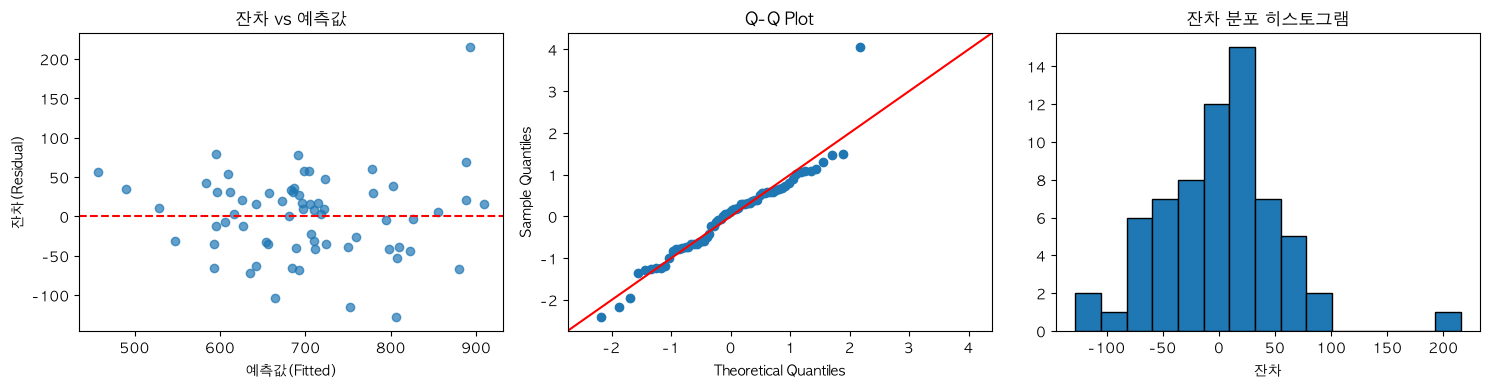

In [7]:
# ── 4-3. 잔차 정규성 / 자기상관 / 이분산성 검정 및 시각화 ──────────────────────────────
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

resid = model.resid
fitted = model.fittedvalues

# Shapiro-Wilk 정규성 검정
shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"Shapiro-Wilk 검정: 통계량={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
print("→", "정규성 가정 충족 (p ≥ 0.05)" if shapiro_p >= 0.05 else "정규성 가정 위배 (p < 0.05)")

# Durbin-Watson (자기상관)
dw = durbin_watson(resid)
print(f"\nDurbin-Watson: {dw:.4f}  (2에 가까울수록 자기상관 없음, 1.5 미만이면 양의 자기상관 의심)")

# Breusch-Pagan (이분산성)
bp_p = het_breuschpagan(resid, X_final)[1]
print(f"Breusch-Pagan(이분산성) p-value: {bp_p:.4f}")

# 가장 큰 잔차를 가진 관측치
max_idx = resid.abs().idxmax()
print(f"\n최대 잔차 관측치: {df.loc[max_idx, '지역']} {df.loc[max_idx, '연도']}년 "
      f"(실제 {y[max_idx]:.1f}, 예측 {fitted[max_idx]:.1f}, 잔차 {resid[max_idx]:.1f})")

# 잔차 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(fitted, resid, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('예측값(Fitted)')
axes[0].set_ylabel('잔차(Residual)')
axes[0].set_title('잔차 vs 예측값')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot')

axes[2].hist(resid, bins=15, edgecolor='black')
axes[2].set_title('잔차 분포 히스토그램')
axes[2].set_xlabel('잔차')

plt.tight_layout()
plt.savefig('visualizations/residual_diagnostics.png', dpi=150)
plt.show()

In [8]:
# ── 4-4. Condition Number 및 표본 대 변수 비율 진단 ──────────────────────────────
print(f"원본 변수 기준 Condition Number: {model.condition_number:,.0f}")

# 변수를 표준화했을 때의 Condition Number (스케일 문제인지 다중공선성 문제인지 구분)
X_std = (X_selected - X_selected.mean()) / X_selected.std()
model_std = sm.OLS(y, sm.add_constant(X_std)).fit()
print(f"표준화 후 Condition Number: {model_std.condition_number:.2f}")

print("\n변수별 스케일(평균 / 표준편차):")
print(X_selected.agg(['mean', 'std']).T.round(3))

print(f"\n표본 수(n) = {len(y)}, 추정 파라미터 수(상수 포함) = {X_final.shape[1]}")
print(f"표본 대 변수 비율 = {len(y) / X_final.shape[1]:.1f}  (권장 기준: 10 이상)")

원본 변수 기준 Condition Number: 901,601
표준화 후 Condition Number: 6.90

변수별 스케일(평균 / 표준편차):
               mean        std
실업률           3.641      0.619
음주율          59.911      3.208
물가상승률         1.862      1.424
경찰1인당주민수    439.258     48.323
조이혼율          1.977      0.251
지역소득      36508.409  15818.215
외국인비율(%)      1.583      0.471
지역_대구         0.167      0.376
지역_대전         0.167      0.376
지역_부산         0.167      0.376

표본 수(n) = 66, 추정 파라미터 수(상수 포함) = 11
표본 대 변수 비율 = 6.0  (권장 기준: 10 이상)


## 5. 종합 검토 결과

### 데이터 검증
- 66행 = 6개 도시 × 11개 연도(2014~2024), 결측치 없음 ✅
- 2018년 이전(2014~2017) 평균 788.17 → 이후(2018~2024) 평균 650.29로 약 -17.5% 감소
- 다만 연도별 평균을 보면 2018년 시점에서 갑자기 끊기는 '불연속'은 아니며, **2014~2021년까지 완만한 하락세 + 2020~2021년 코로나19 시기 추가 하락 + 2022년 이후 소폭 반등**의 추세에 가까움. "2018년 전후 차이"는 추세적 하락의 일부를 절단한 결과로 해석하는 것이 적절함

### 회귀계수 부호 검토
- ❌ **실업률**: 이론(긴장이론)상 (+) 기대되지만 결과는 **-105.9 (p<0.001)** → 가장 우려되는 부호 불일치
- ✅ 음주율(+9.95), 경찰1인당주민수(+0.656), 조이혼율(+94.3): 부호는 이론과 일치하나, 뒤 2개는 p≥0.05로 통계적 유의성 부족
- 물가상승률(-24.8), 지역소득(-0.003), 외국인비율(-50.6): 이론적으로 부호가 사전에 정해진 변수가 아니므로 음수 자체가 "오류"는 아님. 특히 외국인비율의 음수는 통념과 다르지만 다수 실증연구 결과와는 부합

### 통계적으로 유의하지 않은 변수 (p ≥ 0.05)
- 경찰1인당주민수(0.124), 조이혼율(0.206), 지역_대구(0.431), 지역_대전(0.993), 지역_부산(0.110), const(0.136)
- 10개 설명변수 중 5개가 개별적으로는 유의하지 않음

### 잔차 진단
- **Shapiro-Wilk p=0.0054 → 정규성 위배**. 광주 2014년 관측치(잔차 +215.5, 실제 1108.76)가 강한 이상치로 작용해 우측 꼬리를 만듦
- **Durbin-Watson=1.328** → 2보다 작아 양의 자기상관 가능성. 동일 도시가 11개 연도에 걸쳐 반복 관측된 패널 구조를 단순 OLS로 처리해 독립성 가정이 깨졌을 가능성이 큼
- Breusch-Pagan p=0.088 → 5% 수준에서 이분산성이 통계적으로 기각되지는 않으나 경계선에 가까움

### 모델 적합성
- **R²=0.768, Adj. R²=0.726**은 표본 수(66) 대비 변수 수(10+상수=11)가 많아 표본/변수 비율이 6.0(권장 10 이상)에 못 미침 → R²가 다소 과대평가되었을 가능성, 보수적으로 해석 필요
- **Condition Number=901,600**은 지역소득(평균 36,508)처럼 단위(스케일)가 큰 변수와 실업률(평균 3.6) 같은 변수가 함께 있어 발생한 **수치적 인공물**에 가까움. 변수를 표준화하면 Condition Number가 6.9로 떨어져 실제 다중공선성 문제(VIF<10으로 이미 확인)와는 별개임

### 개선 제안
1. 패널데이터 회귀(도시·연도 고정효과 또는 클러스터 표준오차)로 전환 → 자기상관·도시별 이질성 통제
2. 회귀 전 변수 표준화 또는 로그변환(지역소득, 인구수 등 스케일 큰 변수) → Condition Number 개선 및 계수 해석 용이
3. 광주 2014년 이상치에 대한 재검토(자료 오류 여부 확인) 또는 로버스트 회귀 적용
4. 변수 수를 더 줄이거나 표본(연도/도시) 확대로 표본 대 변수 비율 개선
5. 실업률의 반대 부호는 역인과관계, 누락변수, 도시 단위 집계로 인한 생태학적 오류 가능성을 추가 검토

### 최종 판단
모델은 전체적으로 통계적으로 유의(F-test p≈4.3e-14)하고 설명력(R²=0.77)도 높은 편이지만, **① 표본 대 변수 비율이 낮아 과적합 위험, ② 패널 구조 미반영으로 인한 잔차 자기상관, ③ 잔차 비정규성(이상치 영향), ④ 실업률의 이론과 반대되는 부호, ⑤ 다수 변수의 통계적 비유의성**을 고려하면 이 모델을 **인과관계의 근거로 사용하기보다는 변수 간 연관성을 보여주는 탐색적 분석 결과**로 해석하는 것이 타당함.

### 결론에 활용할 한계점 정리
1. 표본 수(n=66) 대비 설명변수 수(10개)가 많아 과적합 가능성이 있음
2. 동일 도시의 반복 관측(패널 구조)을 고려하지 않아 잔차에 자기상관(DW=1.33)이 존재함
3. 잔차가 정규분포를 따르지 않음(Shapiro-Wilk p<0.01) — 광주 2014년 이상치의 영향이 큼
4. 실업률의 회귀계수 부호가 일반적인 범죄이론과 반대(-)로 나타나, 이를 인과관계로 해석할 수 없고 상관관계 수준으로 한정해야 함
5. 조이혼율·경찰1인당주민수·일부 지역 더미는 통계적으로 유의하지 않아 추가 자료나 분석이 필요함
6. Condition Number가 크지만 이는 변수 간 단위 차이에서 비롯된 수치적 현상으로, 표준화 시 6.9로 감소하여 실질적인 다중공선성 문제로 보기는 어려움